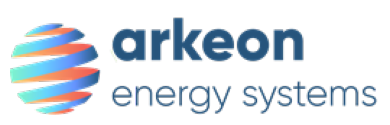

In [12]:
import os
import json
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import ipywidgets as widgets
from IPython.display import Markdown, display

# ============================================================
# Configuration and Setup
# ============================================================
startdate = pd.Timestamp("2026-04-18")
enddate   = pd.Timestamp("2026-04-19")
nowdate = pd.Timestamp.now().normalize()

startdate_str = startdate.strftime("%Y-%m-%d")
enddate_str   = enddate.strftime("%Y-%m-%d")
nowdate_str   = nowdate.strftime("%Y-%m-%d")

generate_pdf = 0
generate_html = 1

# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
SITEDATA_DIR = PROJECT_ROOT / "ResultsData_site"
JUMEAUNUM_DATA_DIR = PROJECT_ROOT / "ResultsData_jumeau_num"

# Display logo only
fig, ax = plt.subplots(figsize=(4, 2))

try:
    logo_path = Path('../images/logo.png')
    if logo_path.exists():
        img = mpimg.imread(logo_path)
        ax.imshow(img)
    ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Logo', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Création des cases à cocher
show_optim = widgets.Checkbox(value=True, description='Optimisation')
show_reel = widgets.Checkbox(value=True, description='Réel Site')
show_jn_site = widgets.Checkbox(value=True, description='JN Ref Site')
show_jn_optim = widgets.Checkbox(value=True, description='JN Ref Optim')

print("Sélectionnez les sources à afficher pour la suite du notebook :")
display(widgets.VBox([show_optim, show_reel, show_jn_site, show_jn_optim]))

Sélectionnez les sources à afficher pour la suite du notebook :


# Vérification et validation des modèles - visualisation

**Site :** Pervenches-Bruyères | **Système :** PAC ARKEON

In [14]:
display(Markdown(f"**Date** : {startdate_str} → {enddate_str}\n\n---"))

**Date** : 2026-04-18 → 2026-04-19

---

Acquisition (optionnel)

## 1. Importation des librairies et des données

In [15]:
# Load data files
optim_file = DATA_DIR / "input_optimisation" / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}.csv"
site_file = SITEDATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_site.csv"
jumeaunum_ref_optim_file = JUMEAUNUM_DATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_JN_ref_OPTIM.csv"
jumeaunum_ref_site_file = JUMEAUNUM_DATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_JN_ref_SITE.csv"

# try to load optimisation results, if missing create empty DataFrame
try:
    results_optim_detail = pd.read_csv(optim_file, sep=';')
except FileNotFoundError:
    print(f"optim file not found: {optim_file}")
    results_optim_detail = pd.DataFrame()

try:
    df_synthese_visu = pd.read_csv(site_file, sep=';')
except FileNotFoundError:
    print(f"site file not found: {site_file}")
    df_synthese_visu = pd.DataFrame()

try:
    df_jn_ref_optim = pd.read_csv(jumeaunum_ref_optim_file, sep=';')
except FileNotFoundError:
    print(f"jumeaunum optim file not found: {jumeaunum_ref_optim_file}")
    df_jn_ref_optim = pd.DataFrame()

try:
    df_jn_ref_site = pd.read_csv(jumeaunum_ref_site_file, sep=';')
except FileNotFoundError:
    print(f"jumeaunum site file not found: {jumeaunum_ref_site_file}")
    df_jn_ref_site = pd.DataFrame()

optim file not found: c:\Users\MohamadJoumaa\Dev\01_Analyse_Pilotage_Pervenches_202602\data\input_optimisation\ResultsTable_18APR26.csv
jumeaunum optim file not found: c:\Users\MohamadJoumaa\Dev\01_Analyse_Pilotage_Pervenches_202602\ResultsData_jumeau_num\ResultsTable_18APR26_JN_ref_OPTIM.csv


## 2. Visualisation : 

### 2.1. Température extérieure

--- Statistiques T_ext ---
T_ext (réel)         - Mean: 15.70°C, Min: 10.66°C, Max: 20.92°C
T_ext (jumeau réel)  - Mean: 15.70°C, Min: 10.66°C, Max: 20.92°C


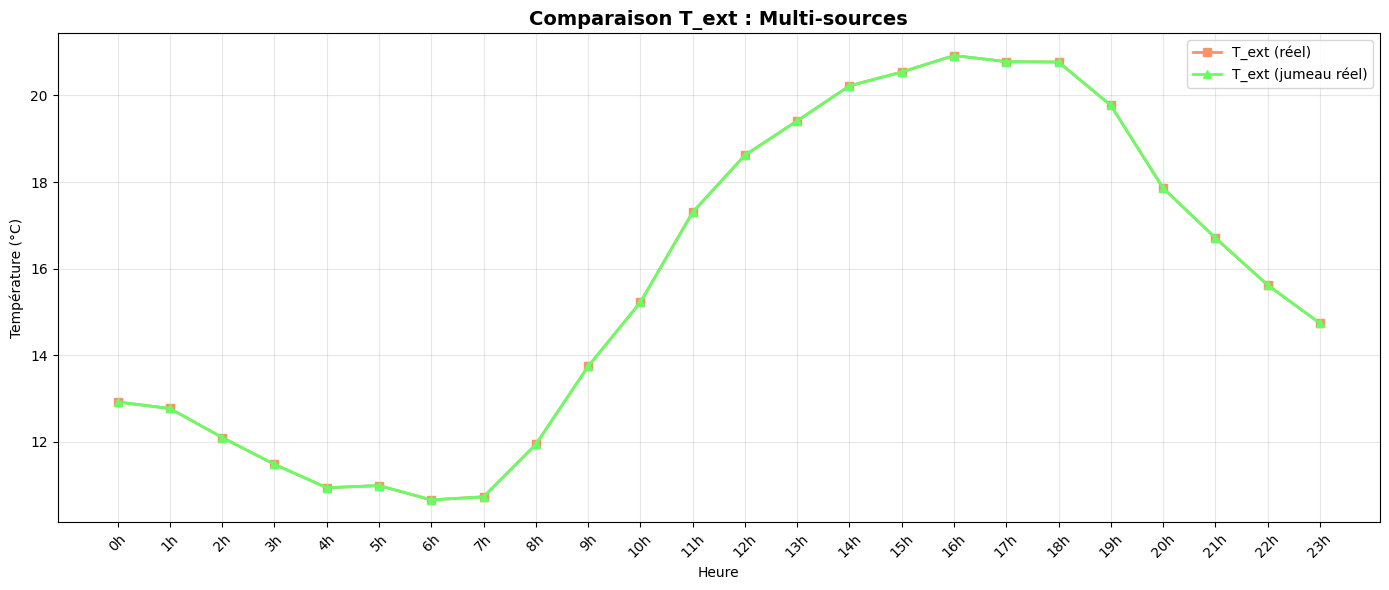

In [16]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'T_ext (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'T_ext (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'T_ext (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'T_ext (jumeau optim)', '#A366FF', 'd') 
]

configs = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques T_ext ---")

for widget, df, label, color, marker in configs:
    if widget.value:  # On vérifie si la case est cochée
        # 1. Tracé
        ax.plot(x, df['T_ext'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Print des stats (dynamique)
        print(f"{label: <20} - Mean: {df['T_ext'].mean():.2f}°C, "
              f"Min: {df['T_ext'].min():.2f}°C, Max: {df['T_ext'].max():.2f}°C")

# Personnalisation finale
ax.set_title('Comparaison T_ext : Multi-sources', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2. Q_base (énergie thermique)

--- Statistiques Q_base ---
Q_base (réel)          - Mean: 10.00 kW, Min: 0.00 kW, Max: 30.00 kW, Sum: 240.00 kWh
Q_base (jumeau réel)   - Mean: 11.05 kW, Min: -0.10 kW, Max: 27.31 kW, Sum: 265.25 kWh


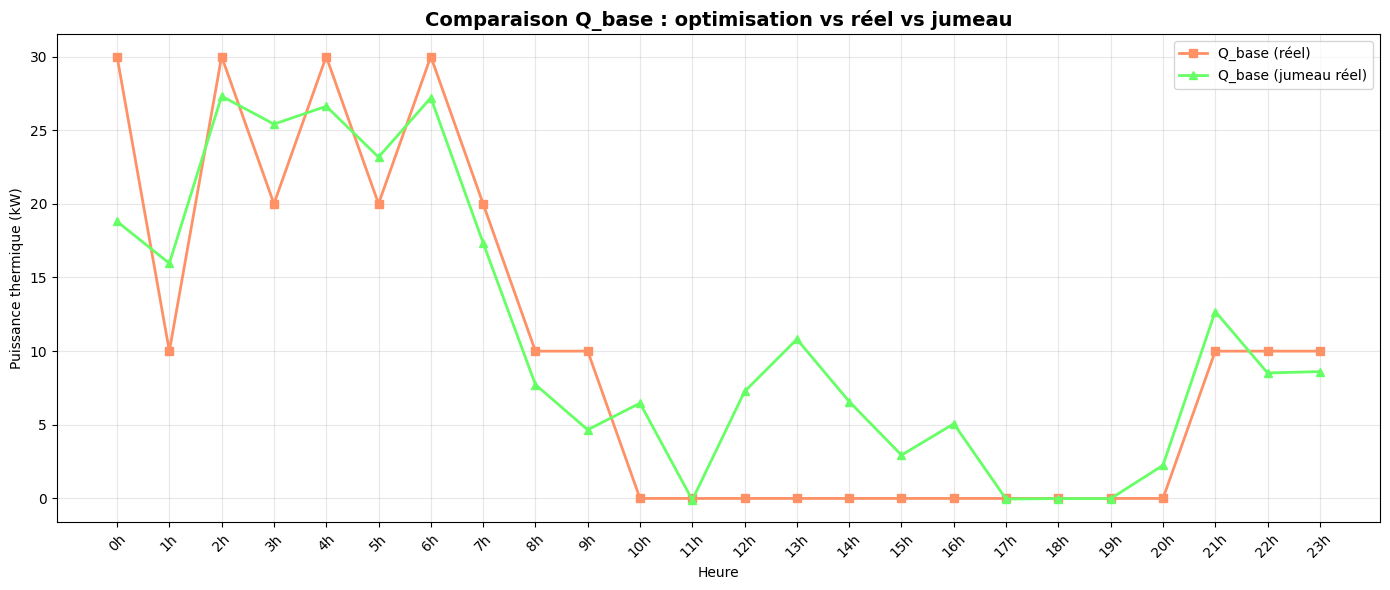

In [17]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'Q_base (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Q_base (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Q_base (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Q_base (jumeau optim)', '#A366FF', 'd') 
]

configs_q = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Q_base ---")

for widget, df, label, color, marker in configs_q:
    if widget.value:  # On vérifie si la case est cochée dans la cellule du haut
        # 1. Tracé de la courbe
        ax.plot(x, df['Q_base'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Affichage des statistiques
        mean_val = df['Q_base'].mean()
        min_val = df['Q_base'].min()
        max_val = df['Q_base'].max()
        sum_val = df['Q_base'].sum()
        
        print(f"{label: <22} - Mean: {mean_val:.2f} kW, Min: {min_val:.2f} kW, "
              f"Max: {max_val:.2f} kW, Sum: {sum_val:.2f} kWh")

# Personnalisation du graphique
ax.set_title('Comparaison Q_base : optimisation vs réel vs jumeau', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Puissance thermique (kW)')

# Graduation des X (adapté pour 24h ou la longueur du DF)
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.3. Prix du MWh élec

--- Statistiques EUR/MWh SPOT ---
EURMWH_SPOT (réel)        - Mean: 47.30 €/MWh, Min: -2.08 €/MWh, Max: 96.63 €/MWh
EURMWH_SPOT (jumeau site) - Mean: 47.30 €/MWh, Min: -2.08 €/MWh, Max: 96.63 €/MWh

--- Statistiques EUR/kWh VARIABLE ---
Coût var (réel)      - Mean: 0.1329 €/kWh, Min: 0.0800 €/kWh, Max: 0.1900 €/kWh
Coût var (jumeau réel) - Mean: 0.1329 €/kWh, Min: 0.0800 €/kWh, Max: 0.1900 €/kWh


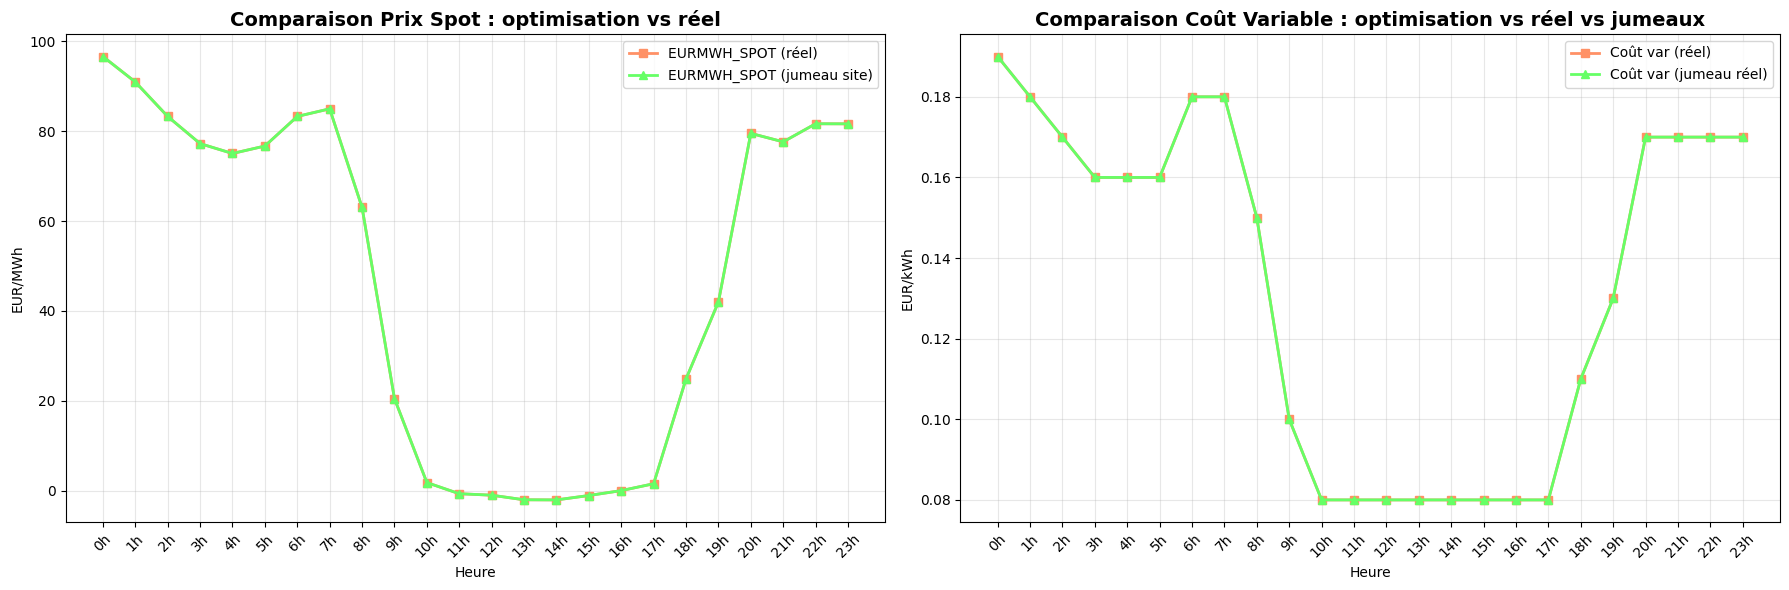

In [18]:
# Configuration de la figure avec 2 graphiques côte à côte
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# ============================================================================
# GRAPHIQUE 1 : Prix SPOT (EUR/MWh)
# ============================================================================
raw_configs_p = [
    (show_optim, results_optim_detail, 'EURMWH_SPOT (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'EURMWH_SPOT (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'EURMWH_SPOT (jumeau site)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'EURMWH_SPOT (jumeau optim)', '#A366FF', 'd') 
]

configs_p = [
    conf for conf in raw_configs_p 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques EUR/MWh SPOT ---")

for widget, df, label, color, marker in configs_p:
    if widget.value and 'EURMWH_SPOT' in df.columns:
        ax1.plot(x, df['EURMWH_SPOT'], marker=marker, linewidth=2, label=label, color=color)
        
        mean_p = df['EURMWH_SPOT'].mean()
        min_p = df['EURMWH_SPOT'].min()
        max_p = df['EURMWH_SPOT'].max()
        
        print(f"{label: <25} - Mean: {mean_p:.2f} €/MWh, Min: {min_p:.2f} €/MWh, Max: {max_p:.2f} €/MWh")

ax1.set_title('Comparaison Prix Spot : optimisation vs réel', fontsize=14, fontweight='bold')
ax1.set_xlabel('Heure')
ax1.set_ylabel('EUR/MWh')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ============================================================================
# GRAPHIQUE 2 : Prix d'électricité part variable (EUR/kWh)
# ============================================================================
raw_configs_v = [
    (show_optim, results_optim_detail, 'Coût var (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Coût var (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Coût var (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Coût var (jumeau optim)', '#A366FF', 'd') 
]

configs_v = [
    conf for conf in raw_configs_v 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("\n--- Statistiques EUR/kWh VARIABLE ---")

for widget, df, label, color, marker in configs_v:
    if widget.value and 'EURKWH_variable' in df.columns:
        ax2.plot(x, df['EURKWH_variable'], marker=marker, linewidth=2, label=label, color=color)
        
        m_var = df['EURKWH_variable'].mean()
        min_var = df['EURKWH_variable'].min()
        max_var = df['EURKWH_variable'].max()
        
        print(f"{label: <20} - Mean: {m_var:.4f} €/kWh, Min: {min_var:.4f} €/kWh, Max: {max_var:.4f} €/kWh")

ax2.set_title('Comparaison Coût Variable : optimisation vs réel vs jumeaux', fontsize=14, fontweight='bold')
ax2.set_xlabel('Heure')
ax2.set_ylabel('EUR/kWh')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4. Température et énergie du stock

--- Statistiques Tst ---
Tst (réel)           - Mean: 44.22 °C, Min: 26.70 °C, Max: 64.70 °C
Tst (jumeau réel)    - Mean: 51.03 °C, Min: 26.72 °C, Max: 66.60 °C

--- Statistiques S_stock ---
S_stock (réel)       - Mean: 169.48 kWh, Min: 67.86 kWh, Max: 288.26 kWh
S_stock (jumeau site) - Mean: 208.95 kWh, Min: 67.95 kWh, Max: 299.25 kWh


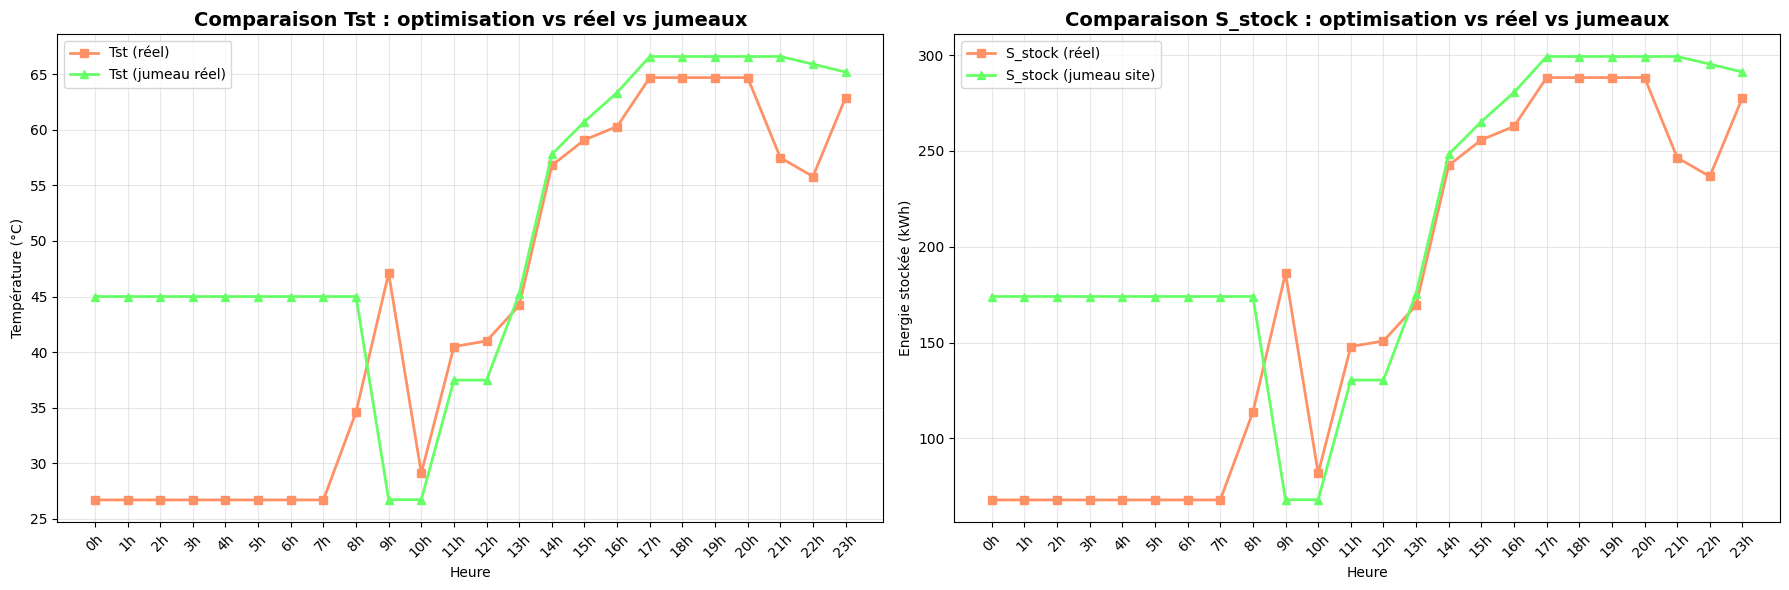

In [19]:
# --- 1. VISUALISATION Tst (Température de stockage) et S_stock (Énergie stockée) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# ============================================================================
# GRAPHIQUE 1 : Tst (Température de stockage)
# ============================================================================
raw_configs_tst = [
    (show_optim, results_optim_detail, 'Tst (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Tst (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Tst (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Tst (jumeau optim)', '#A366FF', 'd') 
]

configs_tst = [
    conf for conf in raw_configs_tst 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Tst ---")
for widget, df, label, color, marker in configs_tst:
    if widget.value and 'Tst' in df.columns:
        ax1.plot(x, df['Tst'], marker=marker, linewidth=2, label=label, color=color)
        print(f"{label: <20} - Mean: {df['Tst'].mean():.2f} °C, Min: {df['Tst'].min():.2f} °C, Max: {df['Tst'].max():.2f} °C")

ax1.set_title('Comparaison Tst : optimisation vs réel vs jumeaux', fontsize=14, fontweight='bold')
ax1.set_xlabel('Heure')
ax1.set_ylabel('Température (°C)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ============================================================================
# GRAPHIQUE 2 : S_stock (Énergie stockée)
# ============================================================================
raw_configs_s = [
    (show_optim, results_optim_detail, 'S_stock (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'S_stock (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'S_stock (jumeau site)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'S_stock (jumeau optim)', '#A366FF', 'd')
]

configs_s = [
    conf for conf in raw_configs_s 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("\n--- Statistiques S_stock ---")
for widget, df, label, color, marker in configs_s:
    if widget.value and 'S_stock' in df.columns:
        ax2.plot(x, df['S_stock'], marker=marker, linewidth=2, label=label, color=color)
        print(f"{label: <20} - Mean: {df['S_stock'].mean():.2f} kWh, Min: {df['S_stock'].min():.2f} kWh, Max: {df['S_stock'].max():.2f} kWh")

ax2.set_title('Comparaison S_stock : optimisation vs réel vs jumeaux', fontsize=14, fontweight='bold')
ax2.set_xlabel('Heure')
ax2.set_ylabel('Energie stockée (kWh)')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5. Consommation électrique totale

--- Statistiques Elec_tot ---
Elec_tot (réel)      - Mean: 9.36 kWh, Min: 1.33 kWh, Max: 40.75 kWh, Total: 224.57 kWh
Elec_tot (jumeau réel) - Mean: 10.76 kWh, Min: 1.08 kWh, Max: 37.51 kWh, Total: 258.30 kWh

--- Statistiques Cost_hour ---
Coût (réel)            - Mean: 1.35 €, Min: 0.49 €, Max: 3.36 €, Total: 32.30 €
Coût (jumeau réel)     - Mean: 1.53 €, Min: 0.47 €, Max: 3.29 €, Total: 36.81 €


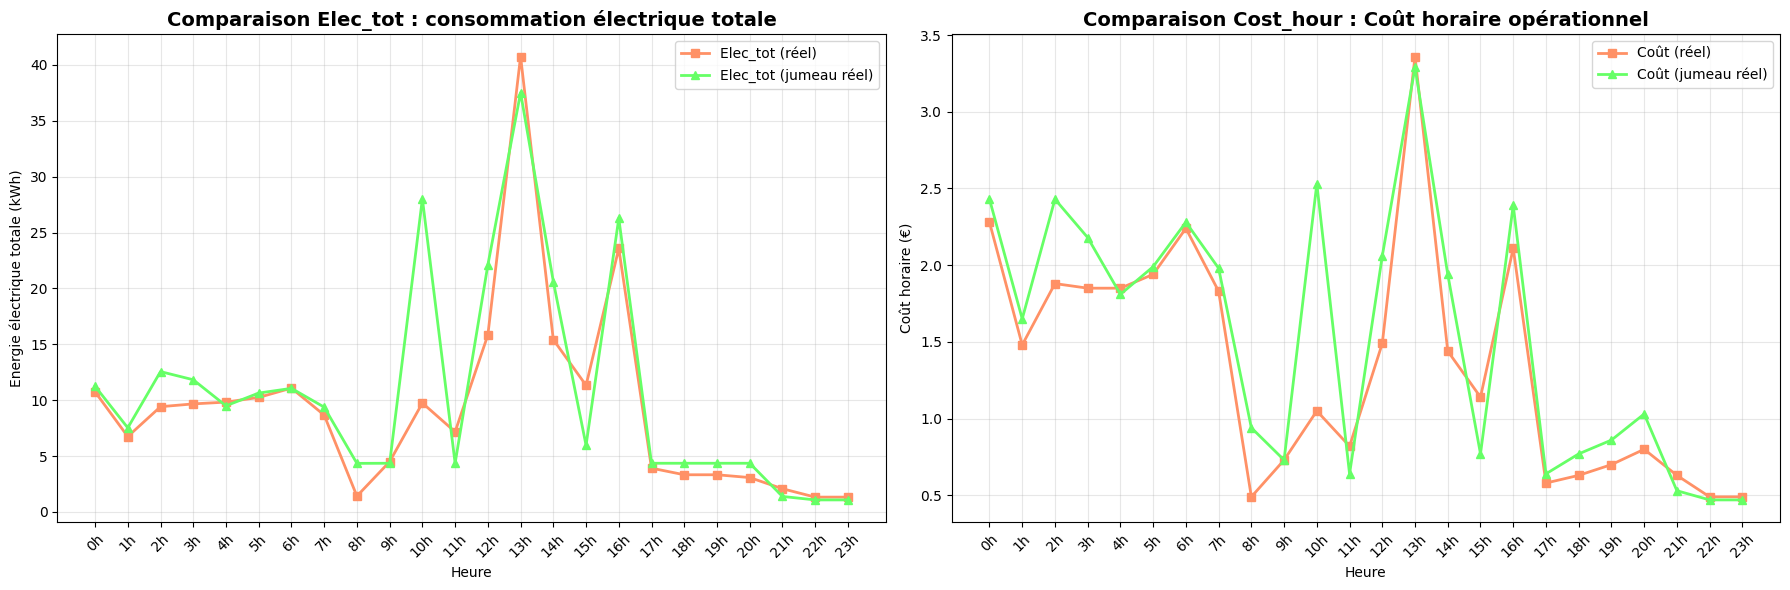

In [20]:
# --- VISUALISATION Elec_tot and Cost_hour (Side by side) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# ============================================================================
# GRAPHIQUE 1 : Consommation électrique totale (Elec_tot)
# ============================================================================
raw_configs_elec = [
    (show_optim, results_optim_detail, 'Elec_tot (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Elec_tot (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Elec_tot (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Elec_tot (jumeau optim)', '#A366FF', 'd') 
]

configs_elec = [
    conf for conf in raw_configs_elec 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Elec_tot ---")

for widget, df, label, color, marker in configs_elec:
    if widget.value and 'Elec_tot' in df.columns:
        ax1.plot(x, df['Elec_tot'], marker=marker, linewidth=2, label=label, color=color)
        
        print(f"{label: <20} - Mean: {df['Elec_tot'].mean():.2f} kWh, "
              f"Min: {df['Elec_tot'].min():.2f} kWh, Max: {df['Elec_tot'].max():.2f} kWh, "
              f"Total: {df['Elec_tot'].sum():.2f} kWh")

ax1.set_title('Comparaison Elec_tot : consommation électrique totale', fontsize=14, fontweight='bold')
ax1.set_xlabel('Heure')
ax1.set_ylabel('Energie électrique totale (kWh)')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ============================================================================
# GRAPHIQUE 2 : Coût horaire opérationnel (Cost_hour)
# ============================================================================
raw_configs_cost = [
    (show_optim, results_optim_detail, 'Coût (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Coût (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Coût (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Coût (jumeau optim)', '#A366FF', 'd') 
]

configs_cost = [
    conf for conf in raw_configs_cost 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("\n--- Statistiques Cost_hour ---")

for widget, df, label, color, marker in configs_cost:
    if widget.value and 'Cost_hour' in df.columns:
        ax2.plot(x, df['Cost_hour'], marker=marker, linewidth=2, label=label, color=color)
        
        c_mean = df['Cost_hour'].mean()
        c_min = df['Cost_hour'].min()
        c_max = df['Cost_hour'].max()
        c_sum = df['Cost_hour'].sum()
        
        print(f"{label: <22} - Mean: {c_mean:.2f} €, Min: {c_min:.2f} €, "
              f"Max: {c_max:.2f} €, Total: {c_sum:.2f} €")

ax2.set_title('Comparaison Cost_hour : Coût horaire opérationnel', fontsize=14, fontweight='bold')
ax2.set_xlabel('Heure')
ax2.set_ylabel('Coût horaire (€)')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# Calculate 'mode' for each existing dataframe
for df_name, df in [('results_optim_detail', results_optim_detail), ('df_synthese_visu', df_synthese_visu), ('df_jn_ref_site', df_jn_ref_site), ('df_jn_ref_optim', df_jn_ref_optim)]:
    if not df.empty:
        df['mode'] = 3 * (df['m_pac_ch'] == 1) + 4 * (df['m_dis'] == 1) + 1 * ((df['m_pac_ch'] != 1) & (df['m_dis'] != 1))
        print(f"Added 'mode' column to {df_name}")



Added 'mode' column to df_synthese_visu
Added 'mode' column to df_jn_ref_site


--- Statistiques mode ---
Réel Site       - Mean: 2.00, Min: 1, Max: 4
JN Ref Site     - Mean: 2.00, Min: 1, Max: 4


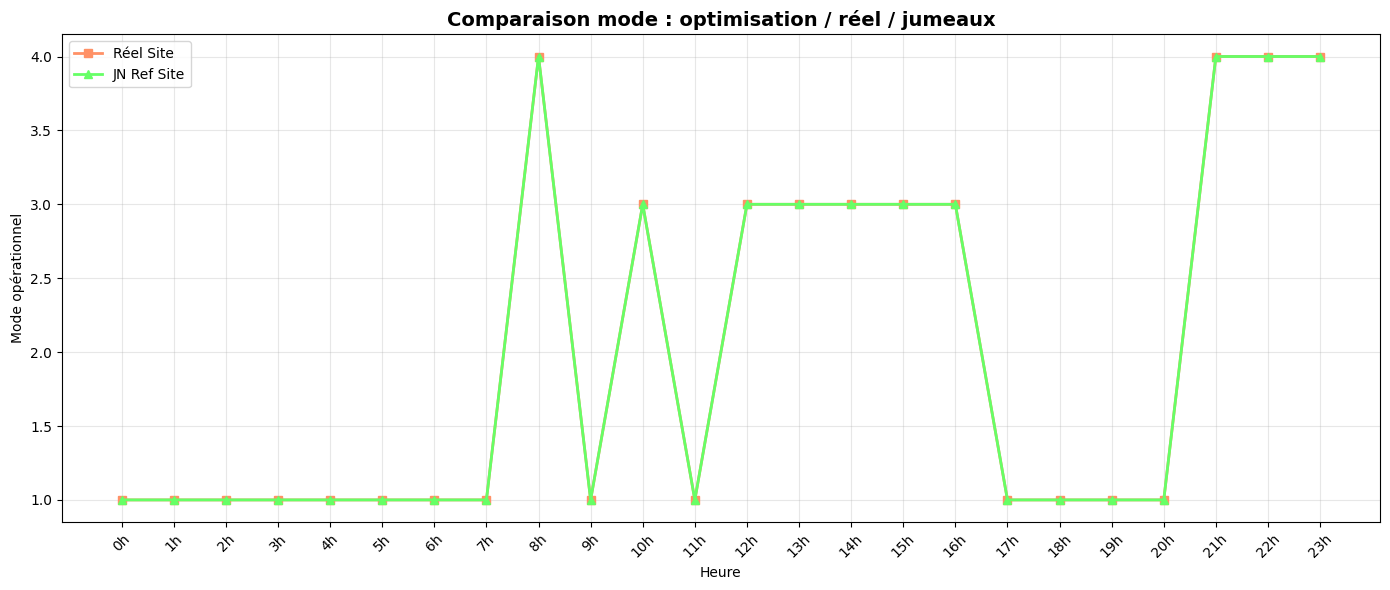

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))

mode_sources = [
    (show_optim, results_optim_detail, 'Optimisation', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Réel Site', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'JN Ref Site', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'JN Ref Optim', '#A366FF', 'd')
]

print("--- Statistiques mode ---")
for widget, df, label, color, marker in mode_sources:
    if widget.value and not df.empty and 'mode' in df.columns:
        x = df['Heure'] if 'Heure' in df.columns else np.arange(len(df))
        ax.plot(x, df['mode'], marker=marker, linewidth=2, label=label, color=color)
        print(f"{label: <15} - Mean: {df['mode'].mean():.2f}, "
              f"Min: {df['mode'].min():.0f}, Max: {df['mode'].max():.0f}")

ax.set_title('Comparaison mode : optimisation / réel / jumeaux', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Mode opérationnel')
ax.set_xticks(np.arange(0, 24, 1))
ax.set_xticklabels([f"{i}h" for i in range(24)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()